In [2]:

import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math

# # import  settings
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

<module 'sim_PyBaMM' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/sim_PyBaMM.py'>

In [ ]:
a = [3.8194,-4.6554,-8.901,19.3256,-11.956,3.2912, 3.2518]

R1 = 0.01

R2 = 0.1


R0 = 3.7 - a[-1]
C1 = 1000
C2 = 500

i0 = 1.0
tf = 3600
Q = 3600
t = np.linspace(0, tf, 1000)

a = a[::-1] 

def dirac_delta(t):
    return np.where(t == 0, 1, 0)

def terms(n,t,a=a, i0=i0, Q=Q):
    n = n
    m = 2 * n -1 
    return a[n] * (i0/Q)**n * t**m / math.factorial(m)


def V_soc(t = t,i0=i0):
    #V = 0
    #for i in range(1,len(a)):
    #    V+= terms(i,t,a,i0,Q)
        
    #V = a[1] * (i0/Q) * t + a[2] * (i0/Q)**2 * t**3 / 6 + a[3] * (i0/Q)**3 * t**5 / 120 + a[4] * (i0/Q)**4 * t**7 / 5040 + a[5] * (i0/Q)**5 * t**9 / 362880 + a[6] * (i0/Q)**6 * t**11 / 39916800
    #return V + a[0] * dirac_delta(t)
    #return a[0] + SOC(i0,t,Q) * a[1] + SOC(i0,t,Q)**2 * a[2] + SOC(i0,t,Q)**3 * a[3] + SOC(i0,t,Q)**4 * a[4] + SOC(i0,t,Q)**5 * a[5] + SOC(i0,t,Q)**6 * a[6]
    t_oc,V_oc = sim_PyBaMM.get_OC_voltage(i0-0.3)
    params = np.polyfit(np.linspace(1,0,len(t_oc)), V_oc, 6)
    p = np.poly1d(params)
    return p(SOC(i0))


def Z(R1, C1, t):
    return R1 * (1 - np.exp(-t / (R1 * C1)))

def simulate(R0, R1, C1,R2,C2, i0 = i0,t = t):
    U = V_soc(SOC(i0)) - i0*(R0 + Z(R1, C1, t) + Z(R2, C2, t))

    return t, U

def SOC(i0, t = t, Q = Q):
    return 1 - i0 * t / Q



#plt.plot(SOC(i0),V_soc(a), label = 'R0 = {}, R1 = {}, C = {}'.format(R0, R1, C))
#plt.plot(t,SOC(i0, t, Q), label = 'R0 = {}, R1 = {}, C = {}'.format(R0, R1, C))




<Figure size 640x480 with 0 Axes>

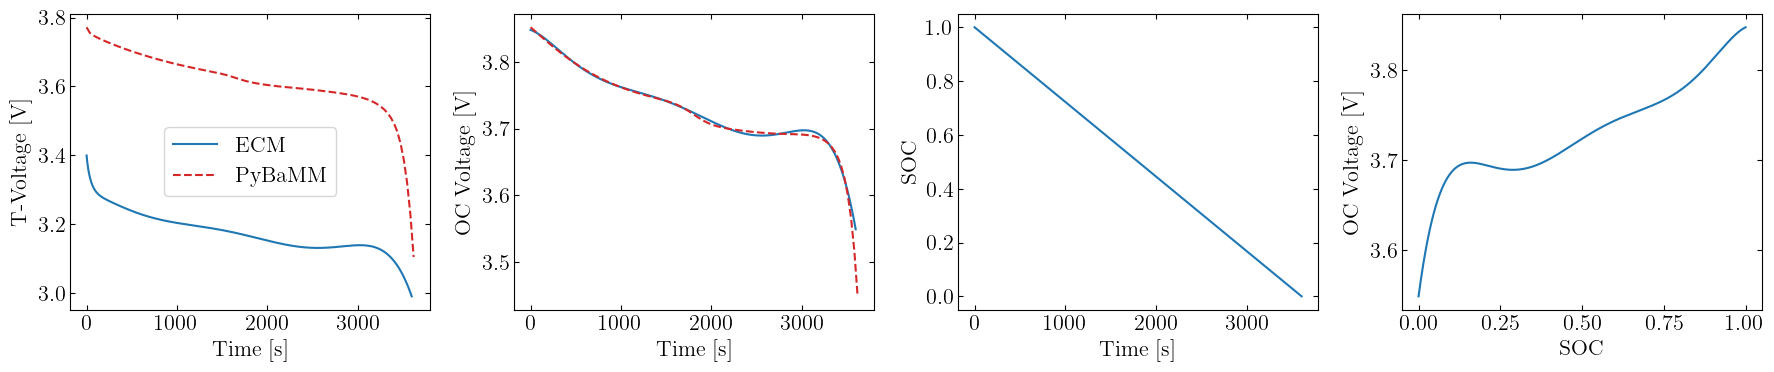

In [4]:
plt.figure()

fig, ax = plt.subplots(1,4, figsize = (18,4))

ax[0].plot(*simulate(R0, R1, C1,R2,C2), label = 'ECM')
ax[0].plot(*sim_PyBaMM.get_voltage(0.68), label = 'PyBaMM', linestyle = '--',color = 'tab:red')
ax[0].legend()
ax[1].plot(t,V_soc(SOC(i0,t,Q)) )
ax[1].plot(*sim_PyBaMM.get_OC_voltage(0.68), label = 'PyBaMM', linestyle = '--',color = 'tab:red')
ax[2].plot(t, SOC(i0,t,Q))
ax[3].plot(SOC(i0),V_soc(SOC(i0)))
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('T-Voltage [V]')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('OC Voltage [V]')
ax[2].set_xlabel('Time [s]')
ax[2].set_ylabel('SOC')
ax[3].set_xlabel('SOC')
ax[3].set_ylabel('OC Voltage [V]')
plt.tight_layout()


[-19.9303013   67.92549898 -89.80676021  57.86564503 -18.48428363
   2.7288873    3.5491122 ]


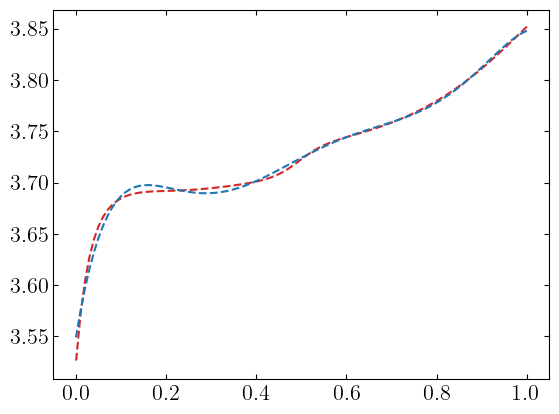

In [47]:
i0 = 1
t_oc,V_oc = sim_PyBaMM.get_OC_voltage(i0)
params = np.polyfit(np.linspace(1,0,len(t_oc)), V_oc, 6)
p = np.poly1d(params)
print(params)
plt.plot(np.linspace(1,0,len(t_oc)), V_oc, label = 'PyBaMM OC Voltage', linestyle = '--',color = 'tab:red')
plt.plot(np.linspace(1,0,len(t_oc)), p(np.linspace(1,0,len(t_oc))), label = 'Fitted OC Voltage', linestyle = '--',color = 'tab:blue')


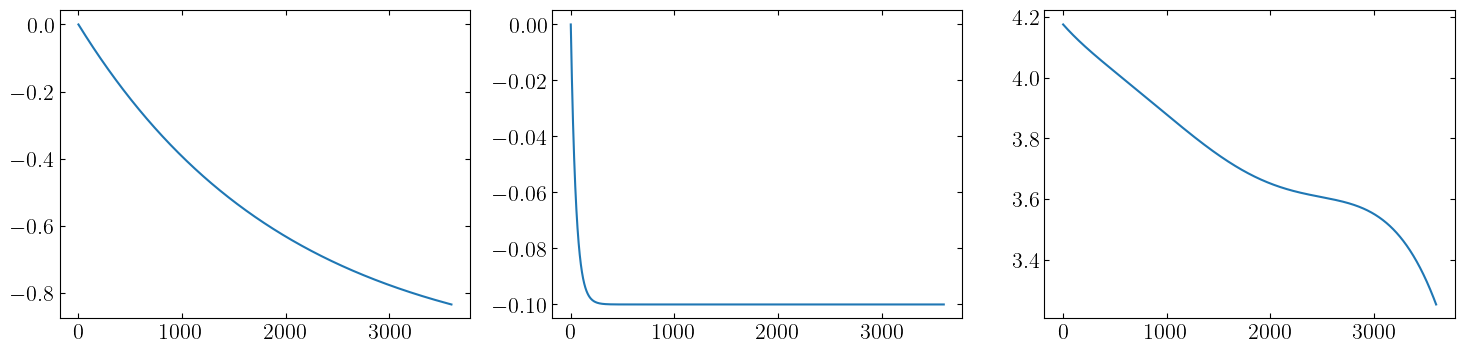

In [13]:
fig, ax = plt.subplots(1,3, figsize = (18,4))
R1 = 1
C1 = 2000
ax[0].plot(t,-i0 * (Z(R1, C1, t)), label = 'Z_1')
ax[1].plot(t,-i0 * (Z(R2, C2, t)), label = 'Z_2')
ax[2].plot(t,V_soc(), label = 'Z_2')

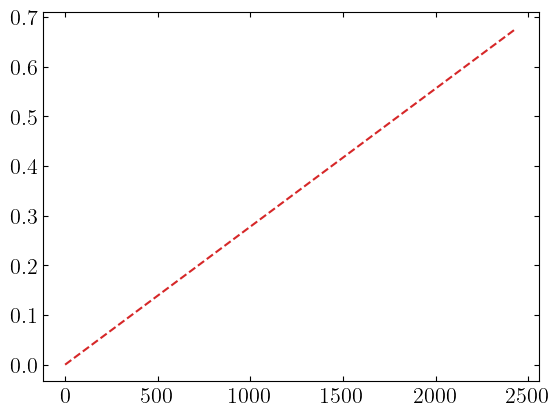

In [34]:
plt.plot(*sim_PyBaMM.get_discharge_capacity(1), label = 'PyBaMM', linestyle = '--',color = 'tab:red')